# Examen Primer Parcial

**Nombre:** Plaza López Cesar Manuel  
**Carrera:** Ingeniería de Sistemas  
**Dataset:** Amharic Spoken Digits Dataset (AmSDD)


### **Importar Librerías y Dispositivo (GPU/CPU). -**

In [1]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando dispositivo: {device}")

Usando dispositivo: cpu


In [6]:
import os
import torch
import torchaudio
import torchaudio.transforms as T
import numpy as np


ruta_dataset = "AmSDD"  

X_list = []
y_list = []


mel_transform = T.MelSpectrogram(
    sample_rate=16000,  
    n_mels=64
)

for digito in range(10):
    carpeta_digito = os.path.join(ruta_dataset, str(digito))
    
    if not os.path.exists(carpeta_digito):
        continue
        
    for archivo in os.listdir(carpeta_digito):
        if archivo.endswith(('.wav', '.mp3', '.flac')):
            ruta_audio = os.path.join(carpeta_digito, archivo)
            
            try:
               
                waveform, sr = torchaudio.load(ruta_audio)
                
               
                mel_spec = mel_transform(waveform)
               
                mel_spec_db = torchaudio.transforms.AmplitudeToDB()(mel_spec)
                
                
                mel_spec_db = mel_spec_db.squeeze(0) 
                
               
                ancho_actual = mel_spec_db.shape[1]
                if ancho_actual >= 81:
                    mel_spec_db = mel_spec_db[:, :81]
                else:
                  
                    padding = torch.zeros(64, 81 - ancho_actual)
                    mel_spec_db = torch.cat([mel_spec_db, padding], dim=1)
                
                X_list.append(mel_spec_db.numpy())
                y_list.append(digito)
                
            except Exception as e:
                print(f"Error procesando {archivo}: {e}")


X_train = np.array(X_list)
y_train = np.array(y_list)

print(f"Forma total de X_train: {X_train.shape}")
print(f"Forma total de y_train: {y_train.shape}")

Forma total de X_train: (12000, 64, 81)
Forma total de y_train: (12000,)


### **División de Entrenamiento y Prueba. -**

In [ ]:
from sklearn.model_selection import train_test_split



X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

print(f"Datos totales para entrenar (antes de recortarlo por procesamiento): {X_train_full.shape}")
print(f"Datos para evaluar al final (Test): {X_test.shape}")


n_muestras = 2000
indices_aleatorios = np.random.permutation(len(X_train_full))

X_subset = X_train_full[indices_aleatorios[:n_muestras]]
y_subset = y_train_full[indices_aleatorios[:n_muestras]]

print(f"\nSubconjunto de entrenamiento recortado por procesamiento a: {X_subset.shape}")

Datos totales para entrenar (antes de recortarlo por procesamiento): (9600, 64, 81)
Datos para evaluar al final (Test): (2400, 64, 81)

Subconjunto de entrenamiento recortado por procesamiento a: (2000, 64, 81)


### **Verificar balanceo en los 2000 datos. -**

In [28]:
import numpy as np


clases, conteos = np.unique(y_subset, return_counts=True)

print("Distribución en 2,000 muestras:")
for clase, conteo in zip(clases, conteos):
    print(f"Dígito {clase}: {conteo} audios")

Distribución en 2,000 muestras:
Dígito 0: 197 audios
Dígito 1: 207 audios
Dígito 2: 206 audios
Dígito 3: 197 audios
Dígito 4: 203 audios
Dígito 5: 182 audios
Dígito 6: 224 audios
Dígito 7: 184 audios
Dígito 8: 190 audios
Dígito 9: 210 audios


### **Conversión a Tensores y Normalizaación. -**

In [29]:
import torch


X_t_raw = torch.from_numpy(X_subset).float()
Y_t = torch.from_numpy(y_subset).long()
X_test_tensor = torch.from_numpy(X_test).float()
Y_test_tensor = torch.from_numpy(y_test).long()


mu = X_t_raw.mean()
sigma = X_t_raw.std()


X_t = (X_t_raw - mu) / sigma
X_test_norm = (X_test_tensor - mu) / sigma

print(f"Media de entrenamiento normalizada: {X_t.mean():.4f}")
print(f"Desviación estándar normalizada: {X_t.std():.4f}")

Media de entrenamiento normalizada: 0.0000
Desviación estándar normalizada: 1.0000


### **Arquitectura de Red neuronal. -**

In [30]:
import torch
import torch.nn as nn
import numpy as np


device = torch.device("cpu")
D_in, H, D_out = 64 * 81, 128, 10

model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(D_in, H),
    nn.ReLU(),
    nn.Dropout(p=0.5),  
    nn.Linear(H, D_out)
).to(device)

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4 )


epochs = 70
log_each = 10
l = []

model.train()

for e in range(1, epochs + 1):
    y_pred = model(X_t)
    loss = criterion(y_pred, Y_t)
    l.append(loss.item())
    
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    
    if not e % log_each:
        print(f"Epoch {e}/{epochs} - Loss {np.mean(l[-log_each:]):.5f}")


Epoch 10/70 - Loss 1.85300
Epoch 20/70 - Loss 1.03877
Epoch 30/70 - Loss 0.69613
Epoch 40/70 - Loss 0.51454
Epoch 50/70 - Loss 0.39512
Epoch 60/70 - Loss 0.31946
Epoch 70/70 - Loss 0.25925


### **Evaluar  usando el test.-**

In [32]:
from sklearn.metrics import accuracy_score


X_test_tensor = torch.from_numpy(X_test).float()
X_test_norm = (X_test_tensor - mu) / sigma


def evaluate(x):
    model.eval()  
    with torch.no_grad(): 
        y_pred = model(x)
        
        return torch.argmax(y_pred, dim=1)


y_pred_tensor = evaluate(X_test_norm.to(device))


accuracy = accuracy_score(y_test, y_pred_tensor.cpu().numpy())

print(f"Exactitud (Accuracy) final del modelo: {accuracy * 100:.2f}%")

Exactitud (Accuracy) final del modelo: 89.54%


## **MÉTRICAS .-**

**Accuracy. -**

In [33]:

def accuracy(y_pred, y):
    return np.sum(y_pred == y) / len(y)


def evaluate(model, x_tensor):
    model.eval()
    with torch.no_grad():
        outputs = model(x_tensor)
        _, predicted = torch.max(outputs, dim=1)
        return predicted.cpu().numpy()


y_pred_train = evaluate(model, X_t)
train_accuracy = accuracy(y_pred_train, y_subset)

y_pred_test = evaluate(model, X_test_norm)
test_accuracy = accuracy(y_pred_test, y_test)

print(f"Exactitud (Accuracy) en Train: {train_accuracy * 100:.2f}%")
print(f"Exactitud (Accuracy) en Test:  {test_accuracy * 100:.2f}%")

Exactitud (Accuracy) en Train: 98.25%
Exactitud (Accuracy) en Test:  89.54%


### **Gráfica de la Curva de Aprendizaje del Entrenamiento (Training Loss Curve).-**

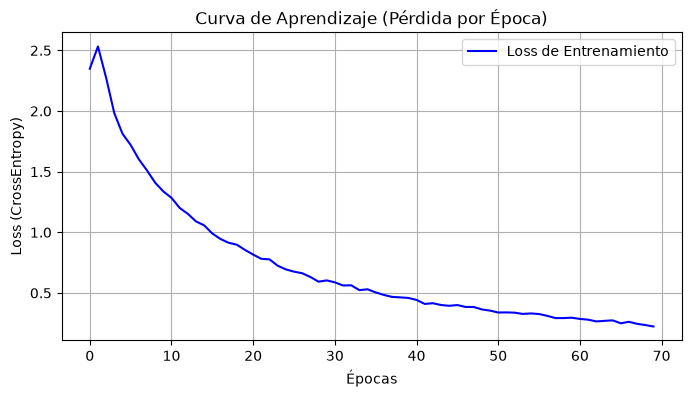

In [34]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(l, label='Loss de Entrenamiento', color='blue')
plt.title('Curva de Aprendizaje (Pérdida por Época)')
plt.xlabel('Épocas')
plt.ylabel('Loss (CrossEntropy)')
plt.legend()
plt.grid(True)
plt.show()

### **Comparación de Espectogramas.-**

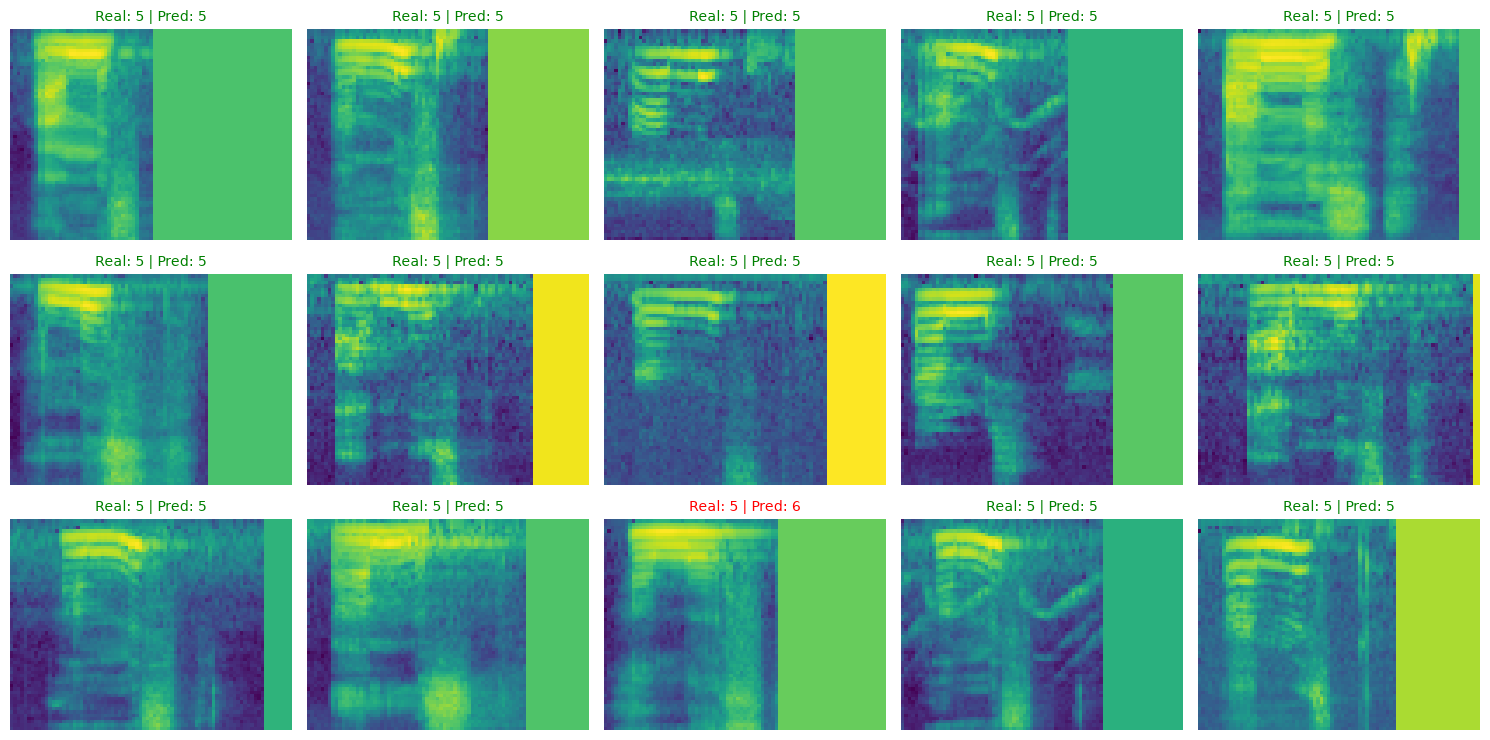

In [ ]:
import random
import matplotlib.pyplot as plt
import torch
import numpy as np

r, c = 3, 5
fig = plt.figure(figsize=(3*c, 2.5*r))


target_digit = 5 
mask = (y_test == target_digit)

for _r in range(r):
    for _c in range(c):
        plt.subplot(r, c, _r*c + _c + 1)
        
   
        indices = np.where(mask)[0]
        if len(indices) == 0:
            print(f"No hay suficientes muestras para el dígito {target_digit}")
            break
            
        ix = random.choice(indices)
        audio_spec = X_test[ix]  
        
        
        plt.imshow(audio_spec, cmap='viridis', aspect='auto')
        plt.axis("off")
        
        
        x_tensor = torch.from_numpy(audio_spec).float().unsqueeze(0).to(device)
        x_norm = (x_tensor - mu) / sigma
        
        
        pred_class = evaluate(model, x_norm)[0]
        true_class = y_test[ix]
        
       
        color = "green" if true_class == pred_class else "red"
        plt.title(f"Real: {true_class} | Pred: {pred_class}", color=color, fontsize=10)

plt.tight_layout()
plt.show()

**Matriz de Confusión. -**

Matriz de Confusión (Array):
 [[218   0   1   2   0   1   4   4   1   9]
 [  0 211   2   2  12   5   1   4   1   2]
 [  2   4 214   3   2   6   0   3   3   3]
 [  2   0   7 217   1   4   3   4   1   1]
 [  0  12   0   0 218   1   1   8   0   0]
 [  0   9   1   4   0 222   4   0   0   0]
 [  2   1   1   6   0   3 219   2   3   3]
 [  6   0   1   7  18   0   0 207   1   0]
 [  8   0   2   3   0   0   5   3 212   7]
 [  8   0   1   2   1   1   4   3   9 211]]


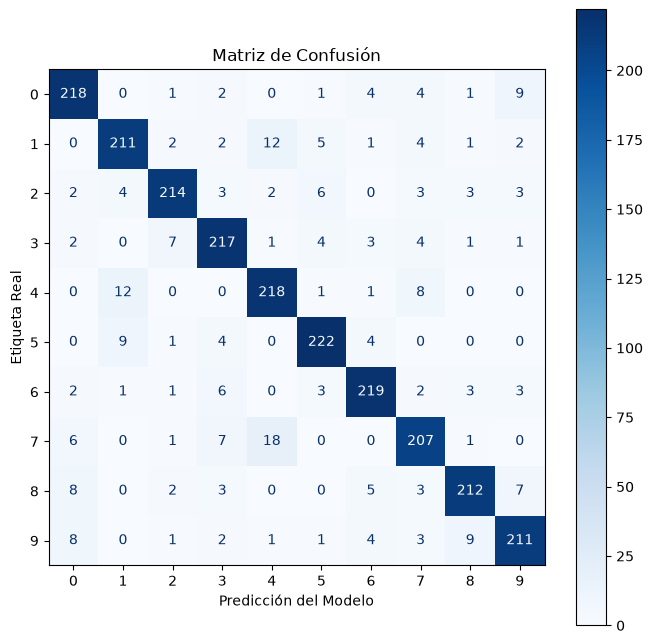

In [36]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


cm = confusion_matrix(y_test, y_pred_test)
print("Matriz de Confusión (Array):\n", cm)


fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=list(range(10)))
disp.plot(cmap=plt.cm.Blues, ax=ax, colorbar=True)
plt.title("Matriz de Confusión", fontsize=12)
plt.xlabel("Predicción del Modelo", fontsize=10)
plt.ylabel("Etiqueta Real", fontsize=10)
plt.show()

 **Precision y Recall. -**

In [37]:
from sklearn.metrics import precision_score, recall_score


precision_final = precision_score(y_test, y_pred_test, average='macro')
recall_final = recall_score(y_test, y_pred_test, average='macro')

print(f"Precisión (Precision) General: {precision_final * 100:.2f}%")
print(f"Recall (Exhaustividad) General:  {recall_final * 100:.2f}%")

Precisión (Precision) General: 89.58%
Recall (Exhaustividad) General:  89.54%


**F1-SCORE. -**

In [38]:
from sklearn.metrics import f1_score

f1_score(y_test, y_pred_test, average='macro')

0.8954369924895247

**La curva ROC.-**

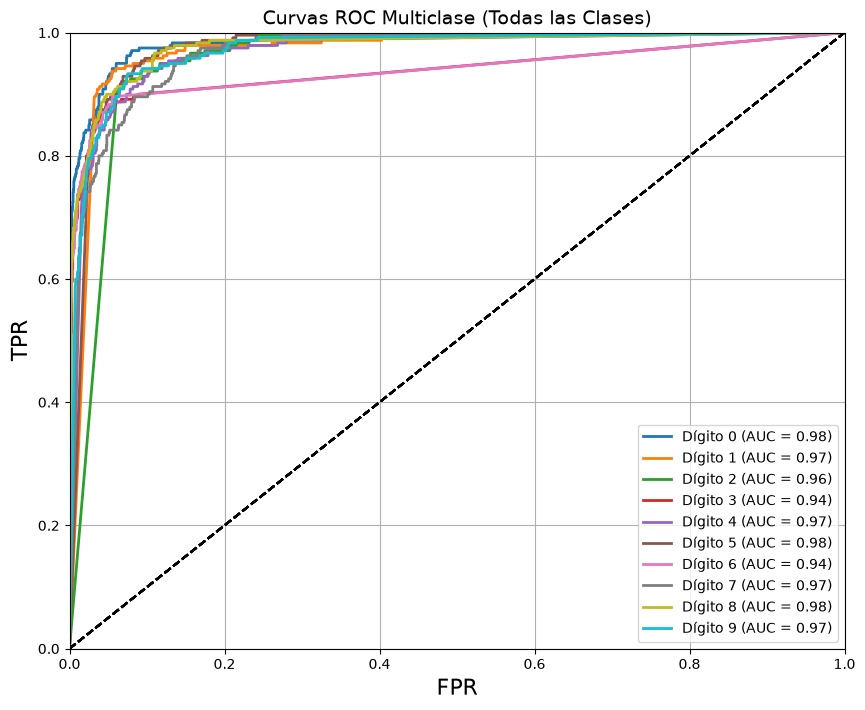

AUC Promedio Multiclase (Macro): 0.9651


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
from sklearn.preprocessing import label_binarize
import torch
import torch.nn.functional as F


model.eval()
with torch.no_grad():
    outputs = model(X_test_tensor)
    y_prob = F.softmax(outputs, dim=1).numpy() 

y_test_bin = label_binarize(y_test, classes=range(10))
n_classes = y_test_bin.shape[1]


def plot_roc_curve(fpr, tpr, label=None):
    plt.plot(fpr, tpr, linewidth=2, label=label)
    plt.plot([0, 1], [0, 1], 'k--') 
    plt.axis([0, 1, 0, 1])                                           
    plt.xlabel('FPR', fontsize=16) 
    plt.ylabel('TPR', fontsize=16)    
    plt.grid(True)                                              


plt.figure(figsize=(10, 8))

for i in range(n_classes):
    
    fpr, tpr, thresholds = roc_curve(y_test_bin[:, i], y_prob[:, i])
    
    auc_clase = roc_auc_score(y_test_bin[:, i], y_prob[:, i])
    
    
    plot_roc_curve(fpr, tpr, label=f'Dígito {i} (AUC = {auc_clase:.2f})')

plt.title("Curvas ROC Multiclase (Todas las Clases)", fontsize=14)
plt.legend(loc="lower right", fontsize=10)
plt.show()


macro_auc = roc_auc_score(y_test, y_prob, multi_class='ovr', average='macro')
print(f"AUC Promedio Multiclase (Macro): {macro_auc:.4f}")